# Algoritmo Genético para o Problema do Caixeiro Viajante (TSP)

**Trabalho Prático — Otimização Evolutiva em Problemas Complexos**  
Disciplina: Computação Evolutiva e Conexionista

---

## Objetivo

Aplicar um **Algoritmo Genético (AG)** para resolver instâncias do **Problema do Caixeiro Viajante (TSP)** — um problema NP-difícil clássico — utilizando benchmarks da **TSPLIB** com ótimos conhecidos.

## Bibliotecas utilizadas

Conforme restrição do professor, o núcleo do AG utiliza apenas:
- `numpy` — operações matemáticas
- `pandas` — organização de dados
- `matplotlib` — visualização

Módulos da **biblioteca padrão** do Python (não são dependências externas):
- `time` — medição de tempo
- `os` — caminhos de arquivo
- `tracemalloc` — medição de consumo de memória

## 1. Importação das Bibliotecas

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import os
import tracemalloc

# Configuração de visualização
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

print("Bibliotecas carregadas com sucesso!")

Bibliotecas carregadas com sucesso!


## 2. Ótimos Conhecidos (TSPLIB)

Para avaliar a **qualidade da solução**, precisamos comparar o resultado do AG com o **ótimo conhecido** de cada instância. A TSPLIB fornece esses valores — todas as instâncias já foram resolvidas exatamente.

O **gap percentual** é calculado como:

$$\text{Gap (\%)} = \frac{\text{Distância encontrada} - \text{Ótimo conhecido}}{\text{Ótimo conhecido}} \times 100$$

Um gap de 0% significa que o AG encontrou a solução ótima.

## 3. Leitura de Arquivos TSPLIB

Os arquivos `.tsp` da TSPLIB seguem um formato padronizado:

```
NAME: berlin52
TYPE: TSP
DIMENSION: 52
EDGE_WEIGHT_TYPE: EUC_2D
NODE_COORD_SECTION
1 565.0 575.0
2 25.0 185.0
...
EOF
```

A função abaixo lê o cabeçalho e extrai as coordenadas de cada cidade.

In [2]:
def read_tsp_file(filepath):
    """
    Lê um arquivo .tsp no formato TSPLIB.

    Retorna: name, dimension, coords (array n×2), edge_weight_type
    """
    name = ""
    dimension = 0
    edge_weight_type = "EUC_2D"
    coords = []
    reading_coords = False

    with open(filepath, "r") as f:
        for line in f:
            line = line.strip()

            if line.startswith("NAME"):
                name = line.split(":")[1].strip()
            elif line.startswith("DIMENSION"):
                dimension = int(line.split(":")[1].strip())
            elif line.startswith("EDGE_WEIGHT_TYPE"):
                edge_weight_type = line.split(":")[1].strip()
            elif line.startswith("NODE_COORD_SECTION"):
                reading_coords = True
                continue
            elif line in ("EOF", "DISPLAY_DATA_SECTION", "DEMAND_SECTION",
                          "DEPOT_SECTION", "EDGE_WEIGHT_SECTION"):
                reading_coords = False
                continue

            if reading_coords and line:
                parts = line.split()
                if len(parts) >= 3:
                    try:
                        x = float(parts[1])
                        y = float(parts[2])
                        coords.append([x, y])
                    except ValueError:
                        reading_coords = False

    coords = np.array(coords)

    if len(coords) != dimension:
        print(f"  [Aviso] Esperado {dimension} cidades, lido {len(coords)}.")
        dimension = len(coords)

    return name, dimension, coords, edge_weight_type

print("Função read_tsp_file definida.")

Função read_tsp_file definida.


## 4. Cálculo da Matriz de Distâncias

Para o tipo **EUC_2D**, a distância entre duas cidades $i$ e $j$ é a distância euclidiana arredondada:

$$d(i, j) = \text{nint}\left( \sqrt{(x_i - x_j)^2 + (y_i - y_j)^2} \right)$$

Usamos **broadcasting do NumPy** para calcular todas as distâncias de uma só vez, evitando loops lentos em Python.

In [3]:
def compute_distance_matrix(coords, edge_weight_type="EUC_2D"):
    """
    Calcula a matriz de distâncias entre todas as cidades.
    Usa broadcasting do NumPy para eficiência.
    """
    if edge_weight_type != "EUC_2D":
        raise ValueError(
            f"Tipo '{edge_weight_type}' não suportado. Use instâncias EUC_2D."
        )

    # diff[i, j, :] = coords[i] - coords[j]
    diff = coords[:, np.newaxis, :] - coords[np.newaxis, :, :]

    # Distância euclidiana, arredondada para inteiro
    dist_matrix = np.sqrt(np.sum(diff ** 2, axis=2))
    dist_matrix = np.rint(dist_matrix).astype(int)

    return dist_matrix

print("Função compute_distance_matrix definida.")

Função compute_distance_matrix definida.


## 5. Representação (Genótipo/Fenótipo) e Função de Fitness

### Representação

No TSP, cada solução é uma **permutação** das cidades. Essa é a forma mais natural de representação:

| Conceito | Descrição |
|----------|-----------|
| **Genótipo** | Permutação de inteiros `[0, 1, 2, ..., n-1]` |
| **Fenótipo** | Rota completa: cidade 3 → cidade 0 → cidade 4 → ... → cidade 3 |

Exemplo com 5 cidades: `[3, 0, 4, 1, 2]` representa a rota `3→0→4→1→2→3`.

### Função de Fitness

O fitness é a **distância total da rota** (somatório de todas as arestas do ciclo). Como queremos **minimizar** a distância, a solução com **menor fitness é a melhor**.

$$\text{Fitness}(\text{tour}) = \sum_{i=0}^{n-1} d(\text{tour}[i],\; \text{tour}[(i+1) \bmod n])$$

In [4]:
def calculate_tour_distance(tour, dist_matrix):
    """
    Calcula a distância total de um tour (ciclo hamiltoniano).
    Usa np.roll para criar pares consecutivos sem loop explícito.
    """
    next_cities = np.roll(tour, -1)  # [tour[1], tour[2], ..., tour[0]]
    return int(np.sum(dist_matrix[tour, next_cities]))


def evaluate_population(population, dist_matrix):
    """Avalia todos os indivíduos e retorna vetor de fitness."""
    return np.array([
        calculate_tour_distance(ind, dist_matrix) for ind in population
    ])

print("Funções de fitness definidas.")

Funções de fitness definidas.


## 6. Inicialização da População

A população inicial é composta por **permutações aleatórias**. Cada indivíduo é automaticamente uma solução **viável** (visita cada cidade exatamente uma vez).

Usar permutações aleatórias garante **diversidade genética** na população inicial, o que é fundamental para o AG explorar diferentes regiões do espaço de busca.

In [5]:
def initialize_population(pop_size, num_cities):
    """
    Gera população inicial: lista de permutações aleatórias.
    Cada indivíduo é um array [0, 1, ..., num_cities-1] embaralhado.
    """
    return [np.random.permutation(num_cities) for _ in range(pop_size)]

# Exemplo visual
example_pop = initialize_population(3, 8)
print("Exemplo de população com 3 indivíduos e 8 cidades:")
for i, ind in enumerate(example_pop):
    print(f"  Indivíduo {i}: {ind}")

Exemplo de população com 3 indivíduos e 8 cidades:
  Indivíduo 0: [2 4 5 1 6 0 7 3]
  Indivíduo 1: [1 4 3 5 2 6 7 0]
  Indivíduo 2: [6 5 1 0 7 4 3 2]


## 7. Seleção por Torneio

A **seleção por torneio** funciona assim:

1. Sorteia `k` indivíduos aleatoriamente da população.
2. O indivíduo com **menor fitness** (menor distância) vence e é selecionado como pai.

O parâmetro `k` (tamanho do torneio) controla a **pressão seletiva**:
- `k = 2` → baixa pressão (mais exploração, diversidade)
- `k = 5-7` → alta pressão (mais exploitação, convergência rápida)

Usamos `k = 5` como padrão, que é um bom equilíbrio.

In [6]:
def tournament_selection(population, fitness, tournament_size):
    """
    Seleciona um indivíduo via torneio.
    Sorteia 'tournament_size' candidatos e retorna o melhor (menor distância).
    """
    candidates = np.random.choice(len(population), tournament_size, replace=False)
    winner = candidates[np.argmin(fitness[candidates])]
    return population[winner].copy()

print("Função tournament_selection definida.")

Função tournament_selection definida.


## 8. Crossover — Order Crossover (OX)

O **Order Crossover (OX)** é um operador de crossover projetado para **permutações**. Diferente do crossover de um ponto (que geraria soluções inválidas com cidades repetidas), o OX preserva a validade da permutação.

### Como funciona:

1. Escolhe dois pontos de corte aleatórios.
2. Copia o segmento entre os cortes do **Pai 1** para o **Filho**.
3. Preenche as posições restantes com cidades do **Pai 2**, na ordem em que aparecem (de forma circular, começando após o segundo corte).

### Exemplo detalhado:

```
Pai 1:  [1, 2, | 3, 4, 5 |, 6, 7]   ← segmento copiado: {3, 4, 5}
Pai 2:  [5, 3,   6, 7, 2,   1, 4]
                                       
Cidades faltando (ordem do Pai 2): 6, 7, 2, 1
Preenchimento circular: posição 6 → 7 → 1 → 2

Filho:  [2, 1, 3, 4, 5, 6, 7]
```

### Por que OX para o TSP?

O OX transmite ao filho a **sub-rota** (segmento consecutivo) de um pai e a **ordem relativa** do outro pai. Isso tende a preservar "bons pedaços" de rota de uma geração para a seguinte.

In [7]:
def order_crossover(parent1, parent2):
    """
    Order Crossover (OX) para permutações.

    1. Copia segmento [start, end] do parent1.
    2. Preenche o resto com cidades do parent2, em ordem circular.
    """
    n = len(parent1)

    # Dois pontos de corte (start < end)
    start, end = sorted(np.random.choice(n, 2, replace=False))

    # Filho vazio
    child = np.full(n, -1, dtype=int)

    # Copia segmento do pai1
    child[start:end + 1] = parent1[start:end + 1]

    # Cidades já presentes no filho
    in_child = set(child[start:end + 1])

    # Cidades do pai2 ainda não no filho, na ordem do pai2
    remaining = [city for city in parent2 if city not in in_child]

    # Preenche de forma circular a partir de (end+1)
    pos = (end + 1) % n
    for city in remaining:
        child[pos] = city
        pos = (pos + 1) % n

    return child

# Demonstração
p1 = np.array([0, 1, 2, 3, 4, 5, 6])
p2 = np.array([4, 2, 5, 6, 1, 0, 3])
filho = order_crossover(p1, p2)
print(f"Pai 1:  {p1}")
print(f"Pai 2:  {p2}")
print(f"Filho:  {filho}")
print(f"Permutação válida? {sorted(filho) == list(range(len(filho)))}")

Pai 1:  [0 1 2 3 4 5 6]
Pai 2:  [4 2 5 6 1 0 3]
Filho:  [0 1 2 3 4 5 6]
Permutação válida? True


## 9. Mutação por Inversão

A **mutação por inversão** seleciona dois pontos aleatórios e **inverte a ordem** das cidades entre eles.

### Exemplo:
```
Antes:   [1, 2, | 3, 4, 5 |, 6, 7]
Depois:  [1, 2, | 5, 4, 3 |, 6, 7]
```

### Por que inversão para o TSP?

A inversão equivale a um **2-opt move**, que é uma das heurísticas mais poderosas para o TSP. Ela "desfaz" cruzamentos de arestas:

```
Antes (arestas se cruzam):      Depois (sem cruzamento):
   A ——→ C                         A ——→ B
     ✕                                ↓
   B ←—— D                         D ←—— C
```

Isso tende a **encurtar a rota** significativamente.

In [8]:
def inversion_mutation(individual):
    """
    Mutação por inversão: reverte um segmento aleatório.
    Preserva a validade da permutação.
    """
    mutant = individual.copy()
    n = len(mutant)

    start, end = sorted(np.random.choice(n, 2, replace=False))
    mutant[start:end + 1] = mutant[start:end + 1][::-1]

    return mutant

# Demonstração
original = np.array([0, 1, 2, 3, 4, 5, 6, 7])
mutado = inversion_mutation(original)
print(f"Original: {original}")
print(f"Mutado:   {mutado}")
print(f"Permutação válida? {sorted(mutado) == list(range(len(mutado)))}")

Original: [0 1 2 3 4 5 6 7]
Mutado:   [0 1 2 6 5 4 3 7]
Permutação válida? True


## 10. Algoritmo Genético — Loop Principal

O AG segue o ciclo evolutivo clássico a cada geração:

```
┌─────────────────────────────────────────────┐
│  1. ELITISMO: copia os N melhores           │
│  2. SELEÇÃO: escolhe pais por torneio       │
│  3. CROSSOVER (OX): gera filhos             │
│  4. MUTAÇÃO (inversão): perturba filhos     │
│  5. SUBSTITUIÇÃO: nova geração completa     │
└─────────────────────────────────────────────┘
```

### Política de substituição: Geracional com Elitismo

- **Geracional**: toda a população é substituída a cada geração.
- **Elitismo**: os `elite_size` melhores indivíduos são copiados diretamente, garantindo que a melhor solução encontrada nunca se perca.

Essa combinação permite explorar novas regiões (geracional) sem perder soluções boas já encontradas (elitismo).

In [9]:
def genetic_algorithm(dist_matrix, params):
    """
    Executa o Algoritmo Genético para o TSP.

    Retorna: best_tour, best_distance, history (dict com 'best' e 'avg')
    """
    num_cities = dist_matrix.shape[0]

    pop_size        = params.get("pop_size", 100)
    n_generations   = params.get("n_generations", 500)
    crossover_rate  = params.get("crossover_rate", 0.8)
    mutation_rate   = params.get("mutation_rate", 0.2)
    tournament_size = params.get("tournament_size", 5)
    elite_size      = params.get("elite_size", 2)

    # Inicialização
    population = initialize_population(pop_size, num_cities)
    fitness = evaluate_population(population, dist_matrix)

    best_history = []
    avg_history = []

    best_idx = np.argmin(fitness)
    global_best_tour = population[best_idx].copy()
    global_best_distance = fitness[best_idx]

    # Loop evolutivo
    for gen in range(n_generations):
        new_population = []

        # ELITISMO: preserva os melhores
        elite_indices = np.argsort(fitness)[:elite_size]
        for idx in elite_indices:
            new_population.append(population[idx].copy())

        # Gera novos indivíduos
        while len(new_population) < pop_size:
            parent1 = tournament_selection(population, fitness, tournament_size)
            parent2 = tournament_selection(population, fitness, tournament_size)

            # Crossover
            if np.random.random() < crossover_rate:
                child1 = order_crossover(parent1, parent2)
                child2 = order_crossover(parent2, parent1)
            else:
                child1 = parent1.copy()
                child2 = parent2.copy()

            # Mutação
            if np.random.random() < mutation_rate:
                child1 = inversion_mutation(child1)
            if np.random.random() < mutation_rate:
                child2 = inversion_mutation(child2)

            new_population.append(child1)
            if len(new_population) < pop_size:
                new_population.append(child2)

        # Substituição geracional
        population = new_population[:pop_size]
        fitness = evaluate_population(population, dist_matrix)

        # Atualiza melhor global
        gen_best_idx = np.argmin(fitness)
        if fitness[gen_best_idx] < global_best_distance:
            global_best_distance = fitness[gen_best_idx]
            global_best_tour = population[gen_best_idx].copy()

        best_history.append(global_best_distance)
        avg_history.append(np.mean(fitness))

    return global_best_tour, global_best_distance, {"best": best_history, "avg": avg_history}

print("Função genetic_algorithm definida.")

Função genetic_algorithm definida.


## 11. Múltiplas Execuções e Coleta de Métricas

Para garantir **relevância estatística**, executamos o AG **múltiplas vezes** (10 runs) com sementes aleatórias diferentes. Isso permite calcular:

| Métrica | Descrição |
|---------|-----------|
| **Melhor distância** | Menor distância entre todas as runs |
| **Média ± Desvio** | Tendência central e variabilidade |
| **Gap percentual** | Qualidade relativa ao ótimo conhecido |
| **Tempo médio** | Custo computacional temporal |
| **Memória pico** | Custo computacional espacial |

### Convergência
Para cada run, registramos o **best fitness** e **average fitness** por geração, o que permite plotar curvas de convergência e analisar se o AG está estagnando prematuramente.

In [10]:
def run_experiment(filepath, params, optimal_distance=None):
    """
    Executa o AG múltiplas vezes para uma instância TSPLIB.
    Coleta métricas de qualidade, tempo e memória.
    """
    name, dimension, coords, edge_weight_type = read_tsp_file(filepath)
    dist_matrix = compute_distance_matrix(coords, edge_weight_type)

    n_runs = params.get("n_runs", 10)

    print(f"\n{'=' * 60}")
    print(f"  Instância: {name} | Cidades: {dimension}")
    if optimal_distance:
        print(f"  Ótimo conhecido: {optimal_distance:,}")
    print(f"  Execuções: {n_runs}")
    print(f"{'=' * 60}")

    results = []
    all_histories = []
    best_overall_tour = None
    best_overall_distance = float("inf")

    for run in range(n_runs):
        tracemalloc.start()
        start_time = time.time()

        best_tour, best_distance, history = genetic_algorithm(dist_matrix, params)

        elapsed_time = time.time() - start_time
        _, peak_memory = tracemalloc.get_traced_memory()
        tracemalloc.stop()

        gap = None
        if optimal_distance:
            gap = ((best_distance - optimal_distance) / optimal_distance) * 100

        results.append({
            "run":            run + 1,
            "best_distance":  best_distance,
            "time_seconds":   round(elapsed_time, 2),
            "peak_memory_mb": round(peak_memory / (1024 * 1024), 2),
            "gap_percent":    round(gap, 2) if gap is not None else None,
        })
        all_histories.append(history)

        if best_distance < best_overall_distance:
            best_overall_distance = best_distance
            best_overall_tour = best_tour.copy()

        gap_str = f"Gap: {gap:.2f}%" if gap is not None else ""
        print(f"  Run {run + 1:2d}/{n_runs}  |  "
              f"Dist: {best_distance:>10,}  |  "
              f"{gap_str:>14s}  |  "
              f"Tempo: {elapsed_time:.2f}s")

    df_results = pd.DataFrame(results)

    stats = {
        "instance":       name,
        "dimension":      dimension,
        "optimal":        optimal_distance,
        "best_found":     int(df_results["best_distance"].min()),
        "worst_found":    int(df_results["best_distance"].max()),
        "mean_distance":  round(df_results["best_distance"].mean(), 2),
        "std_distance":   round(df_results["best_distance"].std(), 2),
        "mean_time":      round(df_results["time_seconds"].mean(), 2),
        "mean_memory_mb": round(df_results["peak_memory_mb"].mean(), 2),
        "best_gap":       round(df_results["gap_percent"].min(), 2) if optimal_distance else None,
        "mean_gap":       round(df_results["gap_percent"].mean(), 2) if optimal_distance else None,
    }

    print(f"\n  Melhor: {stats['best_found']:,}  |  "
          f"Média: {stats['mean_distance']:,.0f} ± {stats['std_distance']:,.0f}")
    if optimal_distance:
        print(f"  Melhor gap: {stats['best_gap']:.2f}%  |  Gap médio: {stats['mean_gap']:.2f}%")

    return df_results, stats, all_histories, best_overall_tour, coords, name

print("Função run_experiment definida.")

Função run_experiment definida.


## 12. Funções de Visualização

Criamos três tipos de gráficos:

1. **Curvas de convergência** — evolução do best/average fitness por geração.
2. **Melhor rota** — visualização 2D da melhor solução encontrada.
3. **Escalabilidade** — tempo e gap vs. número de cidades.

In [11]:
def plot_convergence(all_histories, instance_name, optimal=None, save_path=None):
    """Plota convergência: best e average fitness ao longo das gerações."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    for history in all_histories:
        ax1.plot(history["best"], alpha=0.25, linewidth=0.8, color="steelblue")
    avg_best = np.mean([h["best"] for h in all_histories], axis=0)
    ax1.plot(avg_best, color="darkred", linewidth=2, label="Média das execuções")
    if optimal:
        ax1.axhline(y=optimal, color="green", linestyle="--",
                     linewidth=1.5, label=f"Ótimo = {optimal:,}")
    ax1.set_xlabel("Geração")
    ax1.set_ylabel("Melhor Distância")
    ax1.set_title(f"{instance_name} — Best Fitness")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    for history in all_histories:
        ax2.plot(history["avg"], alpha=0.25, linewidth=0.8, color="steelblue")
    avg_avg = np.mean([h["avg"] for h in all_histories], axis=0)
    ax2.plot(avg_avg, color="darkblue", linewidth=2, label="Média das execuções")
    ax2.set_xlabel("Geração")
    ax2.set_ylabel("Distância Média da População")
    ax2.set_title(f"{instance_name} — Average Fitness")
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


def plot_best_route(tour, coords, distance, instance_name,
                    optimal=None, save_path=None):
    """Plota a melhor rota sobre as coordenadas das cidades."""
    fig, ax = plt.subplots(figsize=(9, 7))

    ax.scatter(coords[:, 0], coords[:, 1],
               c="crimson", s=25, zorder=5, edgecolors="black", linewidths=0.5)

    tour_closed = np.append(tour, tour[0])
    ax.plot(coords[tour_closed, 0], coords[tour_closed, 1],
            "b-", linewidth=0.8, alpha=0.7)

    title = f"{instance_name} — Melhor Rota (Distância: {distance:,})"
    if optimal:
        gap = ((distance - optimal) / optimal) * 100
        title += f"  [Gap: {gap:.2f}%]"
    ax.set_title(title)
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


def plot_scalability(all_stats, save_path=None):
    """Plota tempo e gap vs número de cidades."""
    df = pd.DataFrame(all_stats).sort_values("dimension")

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

    ax1.plot(df["dimension"], df["mean_time"], "o-", color="teal", linewidth=2)
    ax1.set_xlabel("Número de Cidades")
    ax1.set_ylabel("Tempo Médio (s)")
    ax1.set_title("Escalabilidade — Tempo de Execução")
    ax1.grid(True, alpha=0.3)

    ax2.plot(df["dimension"], df["mean_gap"], "s-", color="orangered", linewidth=2)
    ax2.set_xlabel("Número de Cidades")
    ax2.set_ylabel("Gap Médio (%)")
    ax2.set_title("Escalabilidade — Qualidade da Solução")
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


def print_summary_table(all_stats):
    """Exibe tabela resumo formatada."""
    df = pd.DataFrame(all_stats)
    cols = ["instance", "dimension", "optimal", "best_found",
            "mean_distance", "std_distance", "best_gap", "mean_gap",
            "mean_time", "mean_memory_mb"]
    display_names = [
        "Instância", "Cidades", "Ótimo", "Melhor",
        "Média", "Desvio", "Melhor Gap (%)", "Gap Médio (%)",
        "Tempo (s)", "Memória (MB)"
    ]
    df = df[cols]
    df.columns = display_names
    return df

print("Funções de visualização definidas.")

Funções de visualização definidas.


## 13. Execução dos Experimentos

Agora vamos executar o AG para cada instância da TSPLIB.

**Instâncias selecionadas** (todas EUC_2D, com ótimos conhecidos):

| Instância | Cidades | Ótimo | Categoria |
|-----------|---------|-------|-----------|
| berlin52  | 52      | 7.542 | Pequena   |
| eil76     | 76      | 538   | Média     |
| kroA100   | 100     | 21.282| Média     |
| ch150     | 150     | 6.528 | Grande    |
| a280      | 280     | 2.579 | Grande    |

> **Nota:** Os arquivos `.tsp` devem estar na pasta `tsplib/` no mesmo diretório deste notebook. Baixe-os em: http://comopt.ifi.uni-heidelberg.de/software/TSPLIB95/

In [12]:
# Configuração
TSP_DIR = "tsplib"
OUTPUT_DIR = "resultados"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Parâmetros do AG
params = {
    "pop_size":        120,
    "n_generations":   500,
    "crossover_rate":  0.8,
    "mutation_rate":   0.4,
    "tournament_size": 9,
    "elite_size":      8,
    "n_runs":          25,
}

# Instâncias
instances = {
    "berlin52": 7542,
    "eil76":    538,
    "kroA100":  21282,
    "ch150":    6528,
    "a280":     2579,
}

print("Parâmetros do AG:")
for k, v in params.items():
    print(f"  {k:>16s} = {v}")

Parâmetros do AG:
          pop_size = 120
     n_generations = 500
    crossover_rate = 0.8
     mutation_rate = 0.4
   tournament_size = 9
        elite_size = 8
            n_runs = 25


## 15. Busca de Hiperparâmetros (Grid Search)

Nesta etapa, testamos várias combinações de hiperparâmetros do AG e escolhemos automaticamente a melhor com base na **distância média** entre execuções. Em empate, usamos menor desvio padrão e menor tempo médio.

A recomendação é começar com 1 instância (ex.: `berlin52`) para calibrar, e depois validar o conjunto vencedor nas demais instâncias.

In [13]:
# import itertools


# def hyperparameter_search(
#     filepath,
#     optimal_distance,
#     param_grid,
#     fixed_params=None,
#     runs_per_combo=5,
#     top_k=10,
# ):
#     """
#     Testa combinações de hiperparâmetros e retorna ranking por desempenho.

#     Critério de ordenação:
#     1) menor distância média
#     2) menor desvio padrão
#     3) menor tempo médio
#     """
#     fixed_params = fixed_params or {}

#     grid_keys = list(param_grid.keys())
#     grid_values = [param_grid[k] for k in grid_keys]
#     combinations = list(itertools.product(*grid_values))

#     records = []

#     print(f"Total de combinações: {len(combinations)}")
#     print(f"Execuções por combinação: {runs_per_combo}\n")

#     for i, combo in enumerate(combinations, start=1):
#         combo_params = dict(zip(grid_keys, combo))
#         params_test = {
#             **fixed_params,
#             **combo_params,
#             "n_runs": runs_per_combo,
#         }

#         df_results, stats, _, _, _, _ = run_experiment(
#             filepath,
#             params_test,
#             optimal_distance=optimal_distance,
#         )

#         record = {
#             **combo_params,
#             "mean_distance": stats["mean_distance"],
#             "std_distance": stats["std_distance"],
#             "best_found": stats["best_found"],
#             "mean_gap": stats["mean_gap"],
#             "best_gap": stats["best_gap"],
#             "mean_time": stats["mean_time"],
#             "mean_memory_mb": stats["mean_memory_mb"],
#         }
#         records.append(record)

#         print(
#             f"[{i:>3d}/{len(combinations)}] "
#             f"mean={stats['mean_distance']:.2f} | "
#             f"std={stats['std_distance']:.2f} | "
#             f"best={stats['best_found']} | "
#             f"params={combo_params}"
#         )

#     df_grid = pd.DataFrame(records)
#     df_grid = df_grid.sort_values(
#         by=["mean_distance", "std_distance", "mean_time"],
#         ascending=[True, True, True],
#     ).reset_index(drop=True)

#     best_params = {
#         **fixed_params,
#         **{k: df_grid.loc[0, k] for k in grid_keys},
#         "n_runs": runs_per_combo,
#     }

#     print("\nMelhor combinação encontrada:")
#     print(best_params)

#     print(f"\nTop {top_k} combinações:")
#     display(df_grid.head(top_k))

#     return df_grid, best_params


# # Exemplo de uso (ajuste conforme seu tempo de execução)
# instance_name = "berlin52"
# optimal = instances[instance_name]
# filepath = os.path.join(TSP_DIR, f"{instance_name}.tsp")

# fixed_params = {
#     "n_generations": 500,
# }

# param_grid = {
#     "pop_size": [80, 120, 200],
#     "crossover_rate": [0.8, 0.9, 0.95],
#     "mutation_rate": [0.4,0.6],
#     "tournament_size": [7, 9],
#     "elite_size": [2, 4, 6, 8],
# }

# # Atenção: este grid tem muitas combinações; reduza listas para testes rápidos.
# df_hyper, best_hyperparams = hyperparameter_search(
#     filepath=filepath,
#     optimal_distance=optimal,
#     param_grid=param_grid,
#     fixed_params=fixed_params,
#     runs_per_combo=5,
#     top_k=10,
# )

# # Salva ranking completo
# df_hyper.to_csv(os.path.join(OUTPUT_DIR, f"hyperparams_{instance_name}.csv"), index=False)
# print(f"Ranking salvo em {OUTPUT_DIR}/hyperparams_{instance_name}.csv")

# print("\nUse best_hyperparams para rodar o pipeline final.")

In [14]:
# # Execução com os melhores hiperparâmetros encontrados para a instância de calibração
# # Se quiser validar em todas as instâncias, copie best_hyperparams para params no bloco principal.

# params_calibrated = best_hyperparams.copy()

# df_results_best, stats_best, histories_best, best_tour_best, coords_best, name_best = run_experiment(
#     filepath,
#     params_calibrated,
#     optimal_distance=optimal,
# )

# print("\nResumo com hiperparâmetros calibrados:")
# print(stats_best)

# plot_convergence(histories_best, name_best, optimal=optimal)
# plot_best_route(best_tour_best, coords_best, stats_best["best_found"], name_best, optimal=optimal)


  Instância: berlin52 | Cidades: 52
  Ótimo conhecido: 7,542
  Execuções: 25
  Run  1/25  |  Dist:      8,209  |      Gap: 8.84%  |  Tempo: 10.62s
  Run  2/25  |  Dist:      8,406  |     Gap: 11.46%  |  Tempo: 9.05s
  Run  3/25  |  Dist:      8,021  |      Gap: 6.35%  |  Tempo: 9.19s
  Run  4/25  |  Dist:      7,675  |      Gap: 1.76%  |  Tempo: 9.18s
  Run  5/25  |  Dist:      8,964  |     Gap: 18.85%  |  Tempo: 9.09s
  Run  6/25  |  Dist:      8,360  |     Gap: 10.85%  |  Tempo: 9.17s
  Run  7/25  |  Dist:      7,792  |      Gap: 3.31%  |  Tempo: 9.19s
  Run  8/25  |  Dist:      8,157  |      Gap: 8.15%  |  Tempo: 9.16s
  Run  9/25  |  Dist:      8,089  |      Gap: 7.25%  |  Tempo: 9.18s
  Run 10/25  |  Dist:      8,210  |      Gap: 8.86%  |  Tempo: 9.19s
  Run 11/25  |  Dist:      8,510  |     Gap: 12.83%  |  Tempo: 9.08s
  Run 12/25  |  Dist:      8,040  |      Gap: 6.60%  |  Tempo: 9.02s
  Run 13/25  |  Dist:      8,276  |      Gap: 9.73%  |  Tempo: 9.17s
  Run 14/25  |  Dist:   

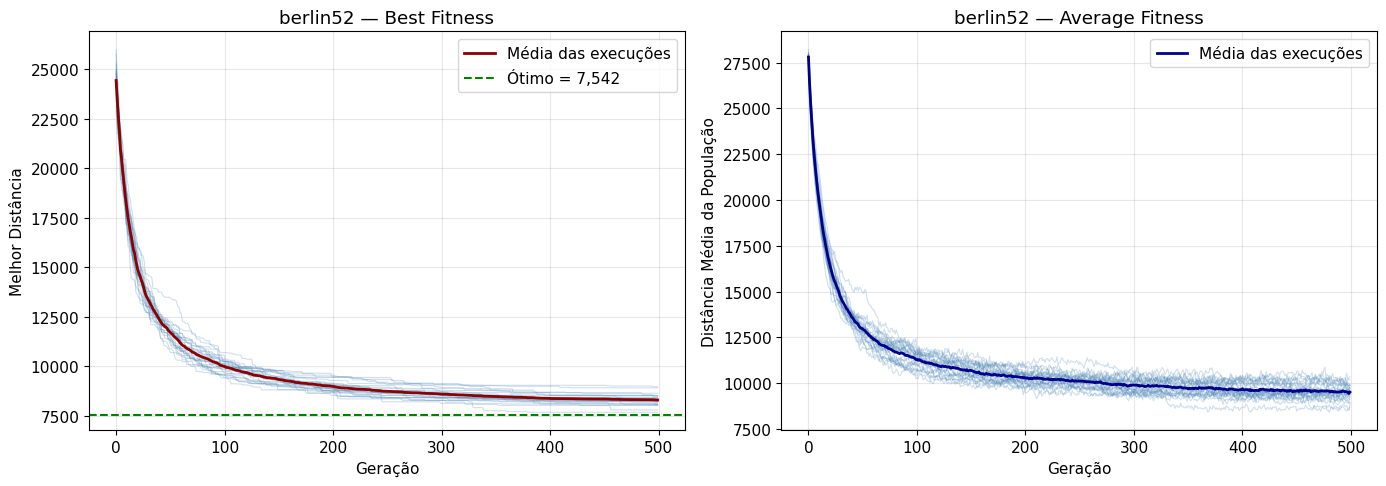

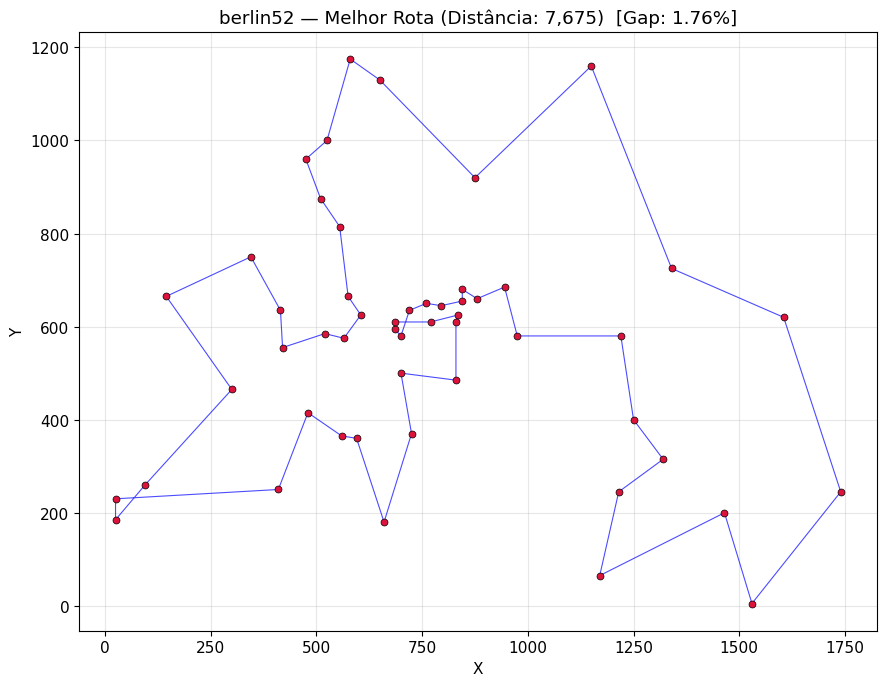


  Instância: eil76 | Cidades: 76
  Ótimo conhecido: 538
  Execuções: 25
  Run  1/25  |  Dist:        616  |     Gap: 14.50%  |  Tempo: 11.21s
  Run  2/25  |  Dist:        650  |     Gap: 20.82%  |  Tempo: 11.99s
  Run  3/25  |  Dist:        645  |     Gap: 19.89%  |  Tempo: 11.20s
  Run  4/25  |  Dist:        635  |     Gap: 18.03%  |  Tempo: 10.95s
  Run  5/25  |  Dist:        662  |     Gap: 23.05%  |  Tempo: 11.01s
  Run  6/25  |  Dist:        631  |     Gap: 17.29%  |  Tempo: 10.99s
  Run  7/25  |  Dist:        609  |     Gap: 13.20%  |  Tempo: 10.95s
  Run  8/25  |  Dist:        620  |     Gap: 15.24%  |  Tempo: 10.95s
  Run  9/25  |  Dist:        670  |     Gap: 24.54%  |  Tempo: 10.88s
  Run 10/25  |  Dist:        613  |     Gap: 13.94%  |  Tempo: 11.24s
  Run 11/25  |  Dist:        624  |     Gap: 15.99%  |  Tempo: 11.33s
  Run 12/25  |  Dist:        622  |     Gap: 15.61%  |  Tempo: 11.41s
  Run 13/25  |  Dist:        597  |     Gap: 10.97%  |  Tempo: 11.59s
  Run 14/25  |  D

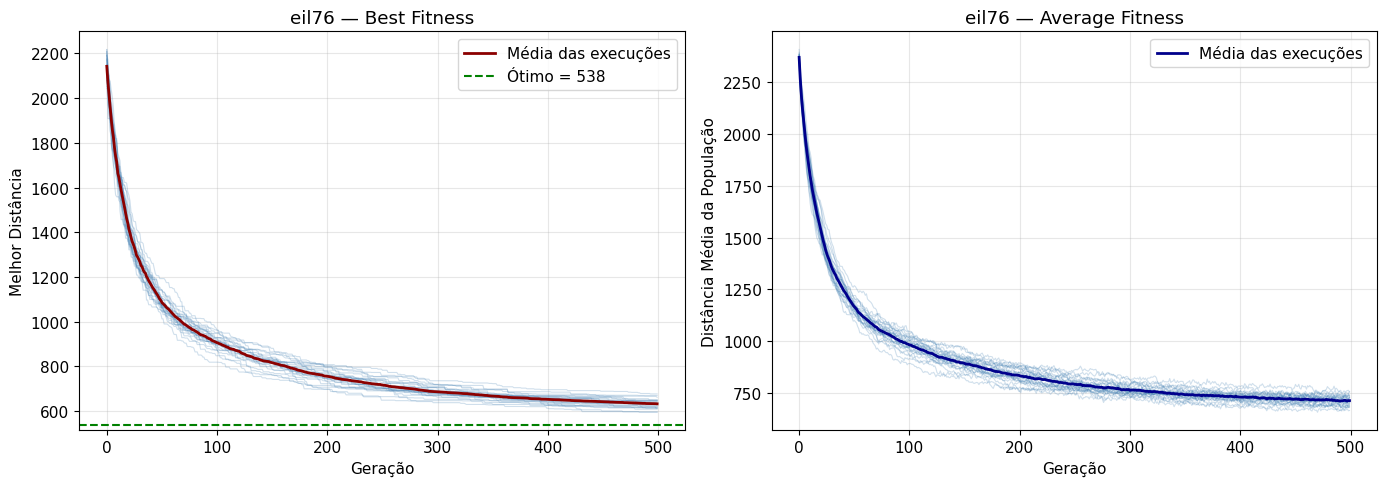

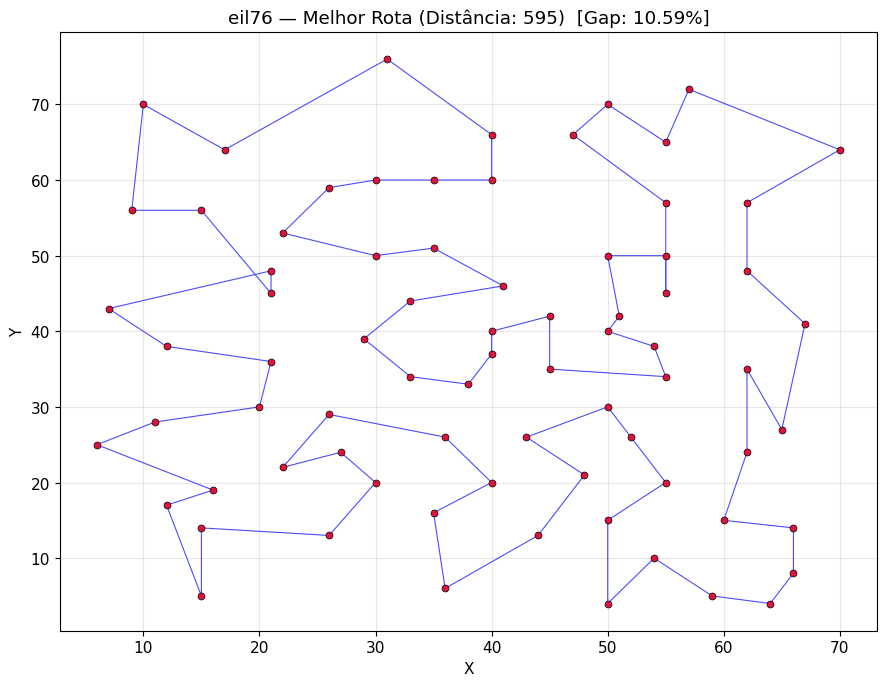


  Instância: kroA100 | Cidades: 100
  Ótimo conhecido: 21,282
  Execuções: 25
  Run  1/25  |  Dist:     30,315  |     Gap: 42.44%  |  Tempo: 12.61s
  Run  2/25  |  Dist:     30,021  |     Gap: 41.06%  |  Tempo: 12.50s
  Run  3/25  |  Dist:     31,618  |     Gap: 48.57%  |  Tempo: 12.49s
  Run  4/25  |  Dist:     30,705  |     Gap: 44.28%  |  Tempo: 12.94s
  Run  5/25  |  Dist:     28,645  |     Gap: 34.60%  |  Tempo: 12.99s
  Run  6/25  |  Dist:     30,482  |     Gap: 43.23%  |  Tempo: 12.92s
  Run  7/25  |  Dist:     31,567  |     Gap: 48.33%  |  Tempo: 12.60s
  Run  8/25  |  Dist:     35,297  |     Gap: 65.85%  |  Tempo: 12.78s
  Run  9/25  |  Dist:     33,869  |     Gap: 59.14%  |  Tempo: 12.47s
  Run 10/25  |  Dist:     31,280  |     Gap: 46.98%  |  Tempo: 12.47s
  Run 11/25  |  Dist:     31,571  |     Gap: 48.35%  |  Tempo: 12.55s
  Run 12/25  |  Dist:     34,004  |     Gap: 59.78%  |  Tempo: 12.48s
  Run 13/25  |  Dist:     32,602  |     Gap: 53.19%  |  Tempo: 12.57s
  Run 14/25

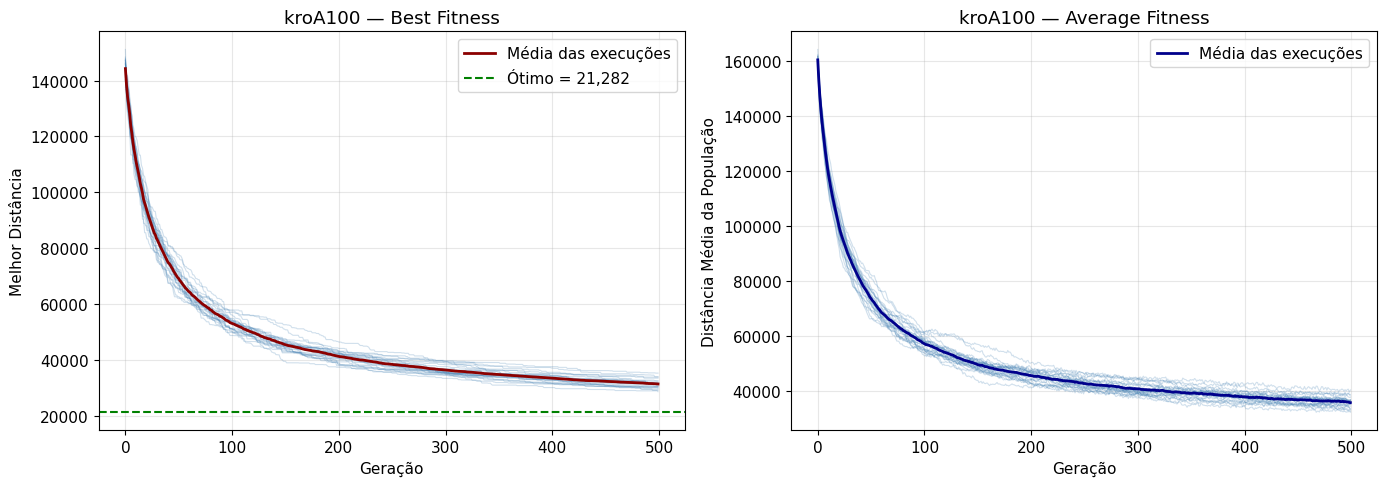

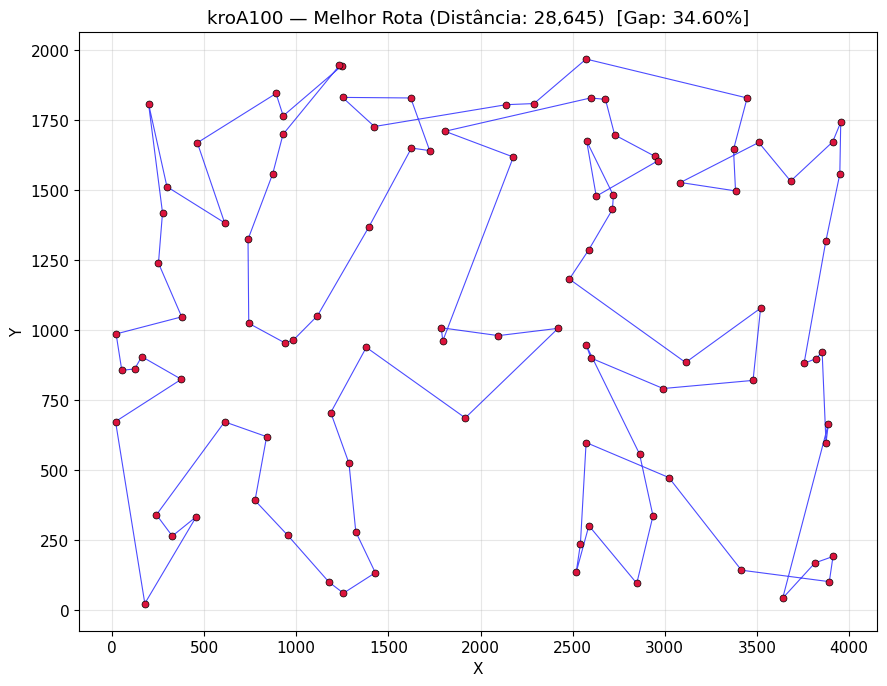


  Instância: ch150 | Cidades: 150
  Ótimo conhecido: 6,528
  Execuções: 25
  Run  1/25  |  Dist:     12,613  |     Gap: 93.21%  |  Tempo: 17.08s
  Run  2/25  |  Dist:     12,193  |     Gap: 86.78%  |  Tempo: 16.69s
  Run  3/25  |  Dist:     13,206  |    Gap: 102.30%  |  Tempo: 17.15s
  Run  4/25  |  Dist:     11,261  |     Gap: 72.50%  |  Tempo: 17.11s
  Run  5/25  |  Dist:     12,906  |     Gap: 97.70%  |  Tempo: 16.56s
  Run  6/25  |  Dist:     12,552  |     Gap: 92.28%  |  Tempo: 16.37s
  Run  7/25  |  Dist:     12,252  |     Gap: 87.68%  |  Tempo: 16.47s
  Run  8/25  |  Dist:     12,940  |     Gap: 98.22%  |  Tempo: 17.02s
  Run  9/25  |  Dist:     12,226  |     Gap: 87.29%  |  Tempo: 16.47s
  Run 10/25  |  Dist:     13,011  |     Gap: 99.31%  |  Tempo: 16.44s
  Run 11/25  |  Dist:     12,857  |     Gap: 96.95%  |  Tempo: 16.41s
  Run 12/25  |  Dist:     12,990  |     Gap: 98.99%  |  Tempo: 16.33s
  Run 13/25  |  Dist:     12,775  |     Gap: 95.70%  |  Tempo: 16.30s
  Run 14/25  |

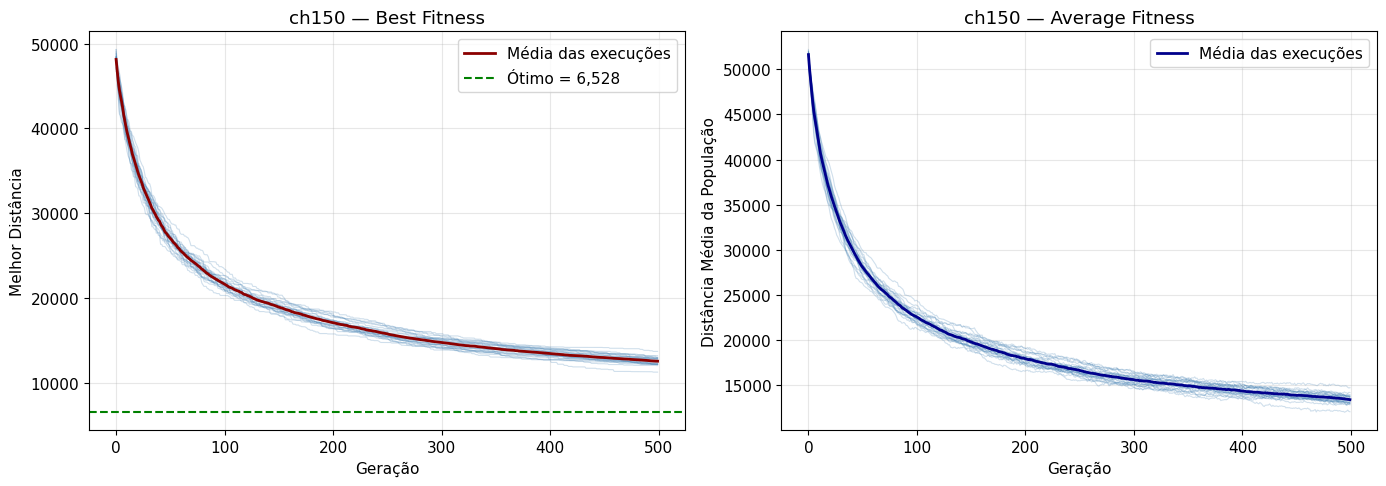

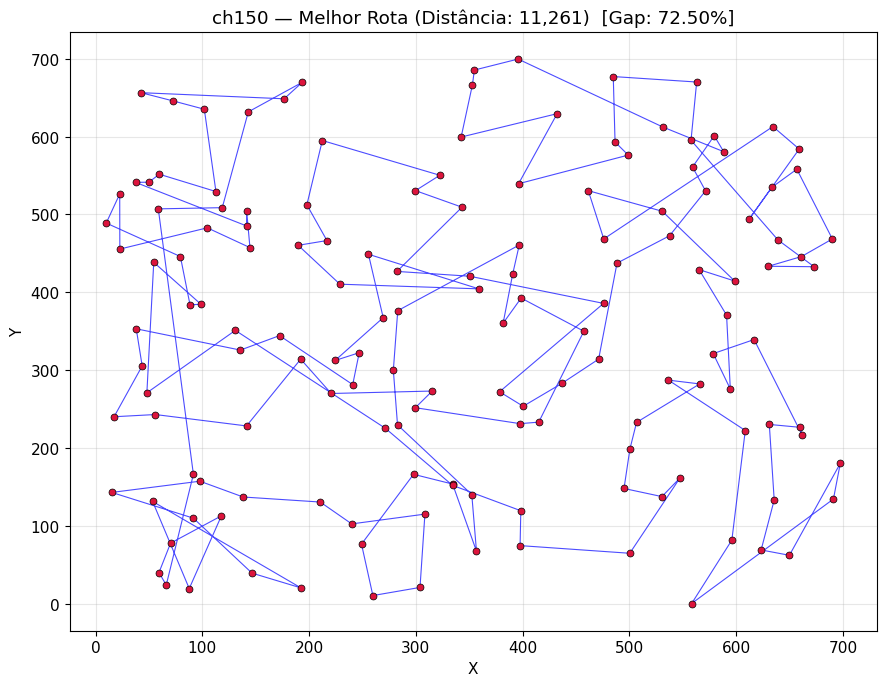


  Instância: a280 | Cidades: 280
  Ótimo conhecido: 2,579
  Execuções: 25
  Run  1/25  |  Dist:      8,584  |    Gap: 232.84%  |  Tempo: 26.27s
  Run  2/25  |  Dist:      8,579  |    Gap: 232.65%  |  Tempo: 25.73s
  Run  3/25  |  Dist:      8,642  |    Gap: 235.09%  |  Tempo: 26.00s
  Run  4/25  |  Dist:      8,578  |    Gap: 232.61%  |  Tempo: 25.83s
  Run  5/25  |  Dist:      8,331  |    Gap: 223.03%  |  Tempo: 25.93s
  Run  6/25  |  Dist:      8,746  |    Gap: 239.12%  |  Tempo: 25.74s
  Run  7/25  |  Dist:      9,007  |    Gap: 249.24%  |  Tempo: 25.74s
  Run  8/25  |  Dist:      8,889  |    Gap: 244.67%  |  Tempo: 26.19s
  Run  9/25  |  Dist:      8,742  |    Gap: 238.97%  |  Tempo: 26.25s
  Run 10/25  |  Dist:      8,565  |    Gap: 232.11%  |  Tempo: 26.18s
  Run 11/25  |  Dist:      8,549  |    Gap: 231.49%  |  Tempo: 25.86s
  Run 12/25  |  Dist:      8,545  |    Gap: 231.33%  |  Tempo: 25.87s
  Run 13/25  |  Dist:      8,715  |    Gap: 237.92%  |  Tempo: 25.95s
  Run 14/25  | 

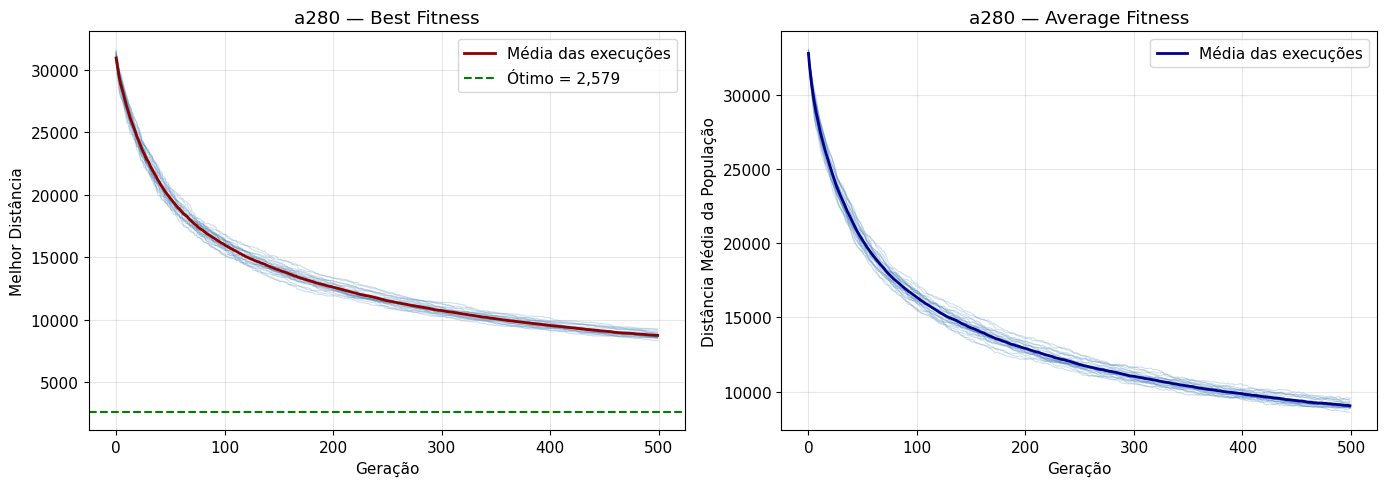

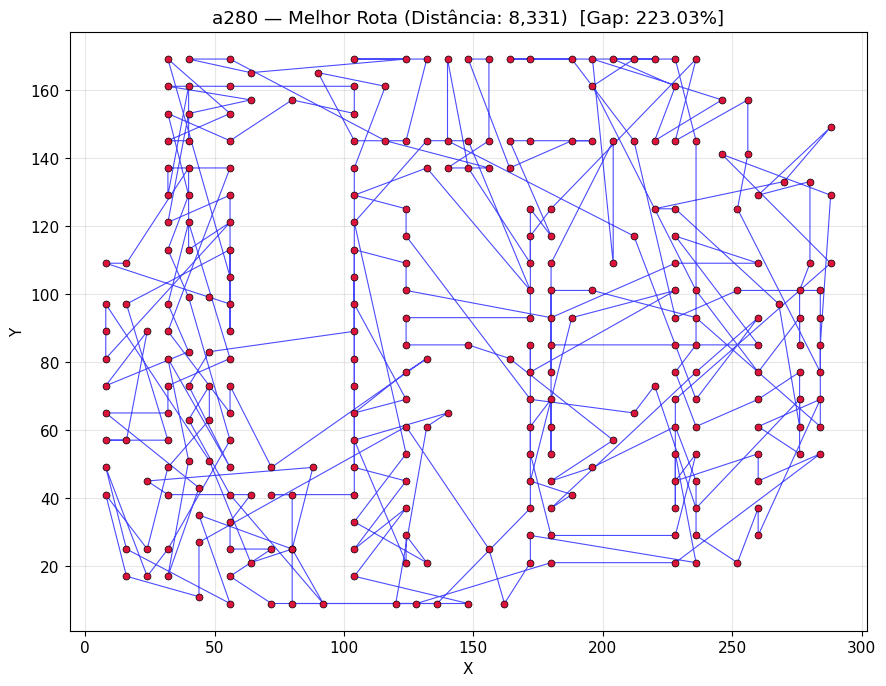

In [ ]:
# Execução principal
all_stats = []

for inst_name, optimal in instances.items():
    filepath = os.path.join(TSP_DIR, f"{inst_name}.tsp")

    if not os.path.exists(filepath):
        print(f"\n[ERRO] Arquivo não encontrado: {filepath}")
        print(f"       Baixe em: http://comopt.ifi.uni-heidelberg.de/software/TSPLIB95/")
        continue

    df_results, stats, histories, best_tour, coords, name = \
        run_experiment(filepath, params, optimal)

    all_stats.append(stats)

    # Gráficos
    plot_convergence(histories, name, optimal=optimal,
                     save_path=os.path.join(OUTPUT_DIR, f"convergencia_{inst_name}.png"))

    plot_best_route(best_tour, coords, stats["best_found"], name, optimal=optimal,
                    save_path=os.path.join(OUTPUT_DIR, f"rota_{inst_name}.png"))

    # Salva CSV com resultados das runs
    df_results.to_csv(os.path.join(OUTPUT_DIR, f"runs_{inst_name}.csv"), index=False)

## 14. Resultados Finais

### Tabela Resumo

A tabela abaixo consolida os resultados de todas as instâncias.

In [17]:
if all_stats:
    df_summary = print_summary_table(all_stats)
    display(df_summary)

    # Salva CSV
    df_summary.to_csv(os.path.join(OUTPUT_DIR, "resumo_geral.csv"), index=False)
    print(f"\nResultados salvos em: {OUTPUT_DIR}/")
else:
    print("Nenhuma instância foi executada. Verifique a pasta 'tsplib/'.")

,Instância,Cidades,Ótimo,Melhor,Média,Desvio,Melhor Gap (%),Gap Médio (%),Tempo (s),Memória (MB)
0,berlin52,52,7542,7675,8292.36,299.26,1.76,9.95,9.24,0.32
1,eil76,76,538,595,632.80,20.95,10.59,17.62,11.05,0.20
2,kroA100,100,21282,28645,31414.96,1584.00,34.60,47.61,12.70,0.25
3,ch150,150,6528,11261,12550.04,491.11,72.50,92.25,16.41,0.35
4,a280,280,2579,8331,8728.92,224.95,223.03,238.46,25.95,0.60



Resultados salvos em: resultados/


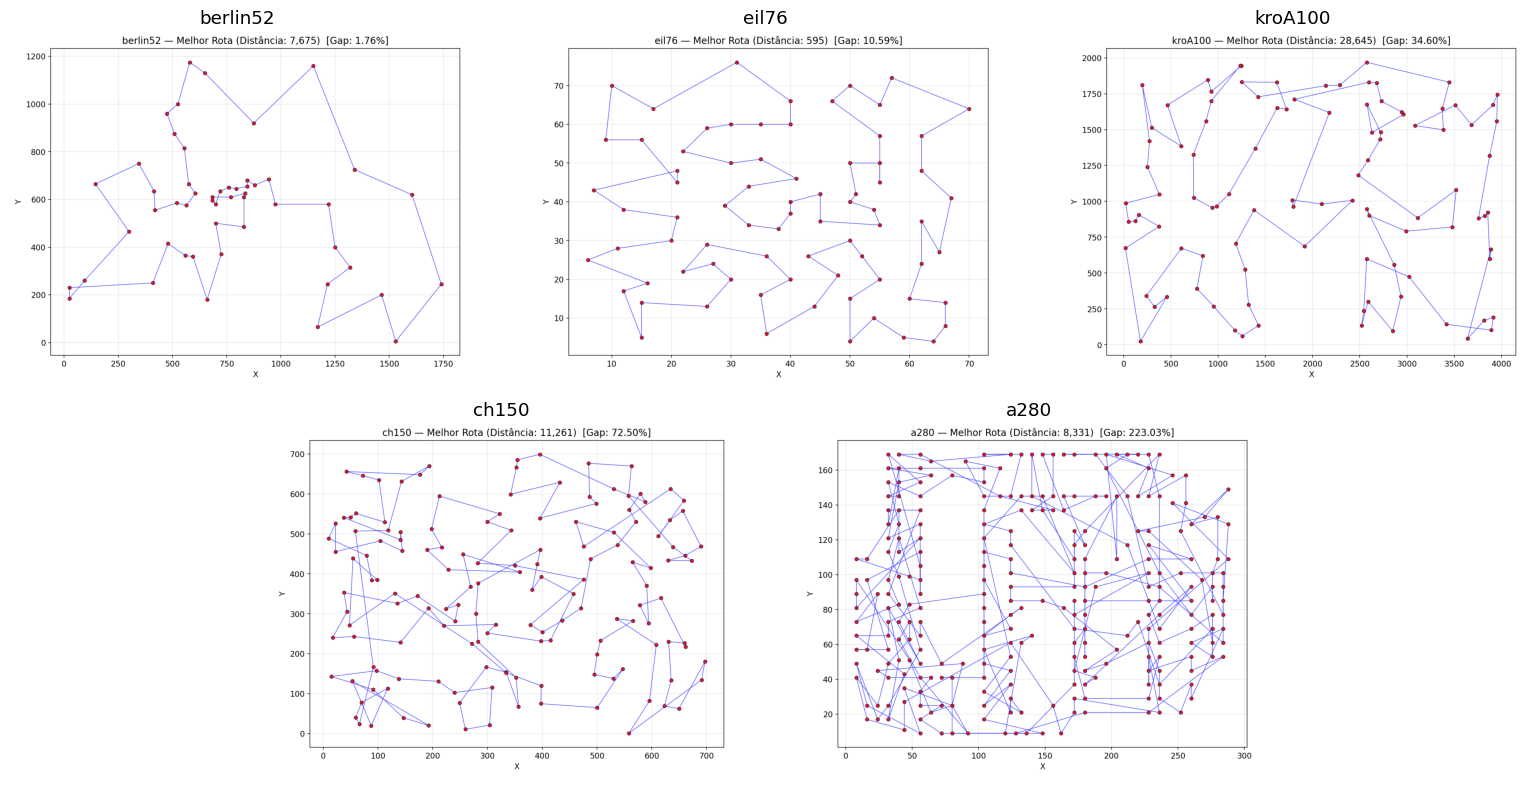

In [11]:
# Subplots das rotas salvas: 3 em cima + 2 centralizadas embaixo (sem sobra lateral)
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

OUTPUT_DIR = "resultados"
instances = {
"berlin52": 7542,
"eil76": 538,
"kroA100": 21282,
"ch150": 6528,
"a280": 2579,
}
# Mantém a ordem definida no dicionário 'instances'
ordered_instances = list(instances.keys())
route_files = [os.path.join(OUTPUT_DIR, f"rota_{name}.png") for name in ordered_instances]

# Filtra apenas os arquivos que realmente existem, preservando a ordem
route_files = [f for f in route_files if os.path.exists(f)]

if len(route_files) < 5:
    print("Este layout foi pensado para 5 imagens (3 + 2).")
    print(f"Encontradas: {len(route_files)}")
else:
    # Usa apenas as 5 primeiras para manter o layout pedido
    route_files = route_files[:5]

    fig = plt.figure(figsize=(16, 8))
    gs = fig.add_gridspec(2, 6)

    # Topo: 3 imagens ocupando a largura inteira
    # Base: 2 imagens centralizadas com margens iguais (1 coluna de cada lado)
    target_axes = [
        fig.add_subplot(gs[0, 0:2]),
        fig.add_subplot(gs[0, 2:4]),
        fig.add_subplot(gs[0, 4:6]),
        fig.add_subplot(gs[1, 1:3]),
        fig.add_subplot(gs[1, 3:5]),
    ]

    for ax, img_path in zip(target_axes, route_files):
        img = mpimg.imread(img_path)
        ax.imshow(img)
        inst_name = os.path.basename(img_path).replace("rota_", "").replace(".png", "")
        ax.set_title(inst_name)
        ax.axis("off")

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "comparacao_rotas_3x2_centralizado.png"), dpi=150, bbox_inches="tight")
    plt.show()

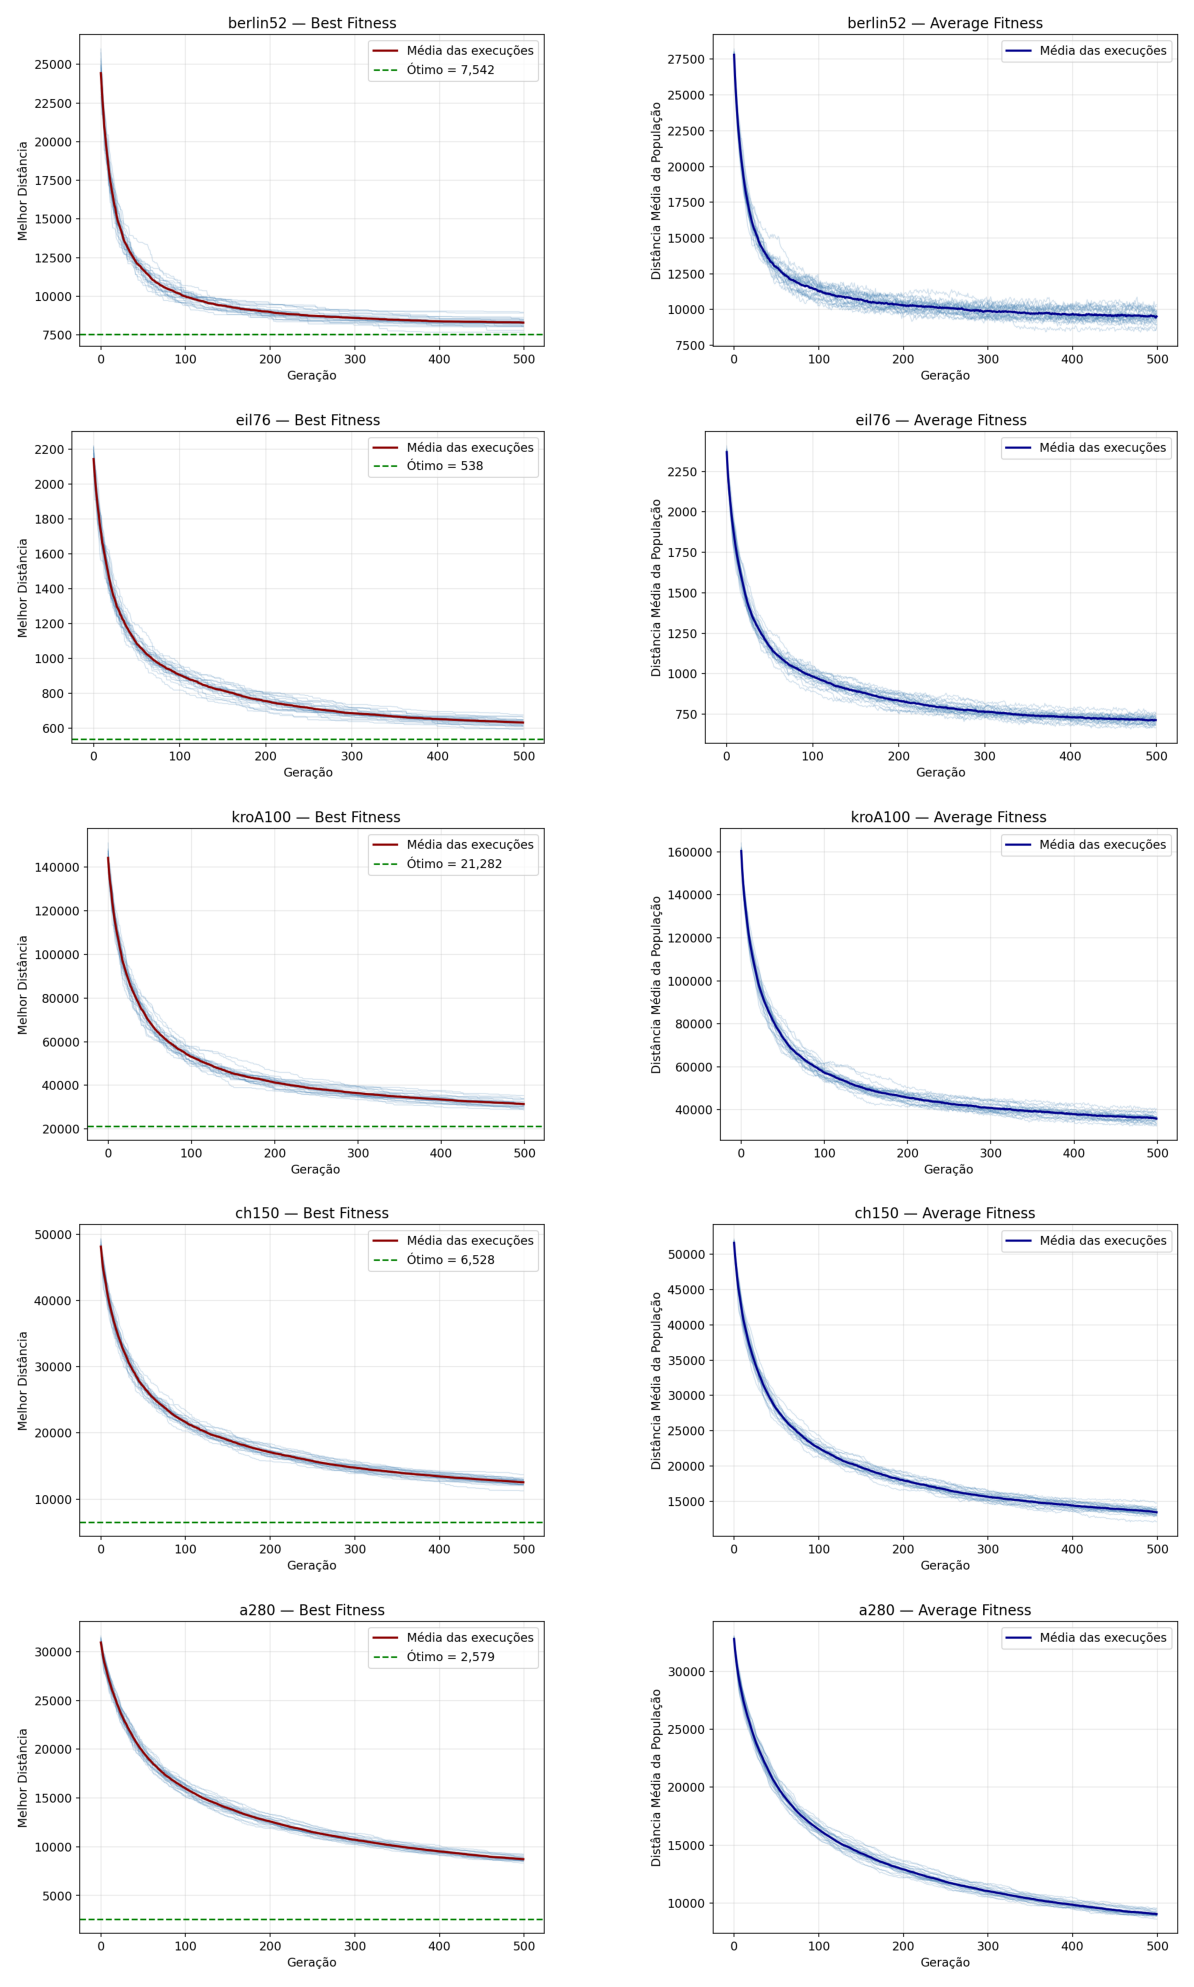

In [13]:
# Grid usando dados salvos (sem reexecutar):
# recorta os PNGs de convergencia em 2 partes: best (esquerda) e avg (direita)
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

OUTPUT_DIR = "resultados"
ordered_instances = list(instances.keys())

# Usa apenas instancias que possuem PNG de convergencia salvo
available = [
    name for name in ordered_instances
    if os.path.exists(os.path.join(OUTPUT_DIR, f"convergencia_{name}.png"))
]

if not available:
    print("Nenhum arquivo convergencia_<instancia>.png encontrado em resultados/.")
else:
    n_inst = len(available)
    fig, axes = plt.subplots(n_inst, 2, figsize=(14, 4.0 * n_inst), squeeze=False)

    for i, inst_name in enumerate(available):
        img_path = os.path.join(OUTPUT_DIR, f"convergencia_{inst_name}.png")
        img = mpimg.imread(img_path)

        # Divide a imagem ao meio: esquerda=Best, direita=Avg
        h, w = img.shape[:2]
        mid = w // 2
        img_best = img[:, :mid]
        img_avg = img[:, mid:]

        ax_best = axes[i, 0]
        ax_avg = axes[i, 1]

        ax_best.imshow(img_best)
        ax_avg.imshow(img_avg)

        #ax_best.set_title(f"{inst_name} - Best fitness")
        #ax_avg.set_title(f"{inst_name} - Avg fitness")
        ax_best.axis("off")
        ax_avg.axis("off")

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "convergencia_grid_best_avg_from_saved.png"), dpi=150, bbox_inches="tight")
    plt.show()

### Análise de Escalabilidade

O gráfico abaixo mostra como o **tempo de execução** e o **gap percentual** variam com o número de cidades.

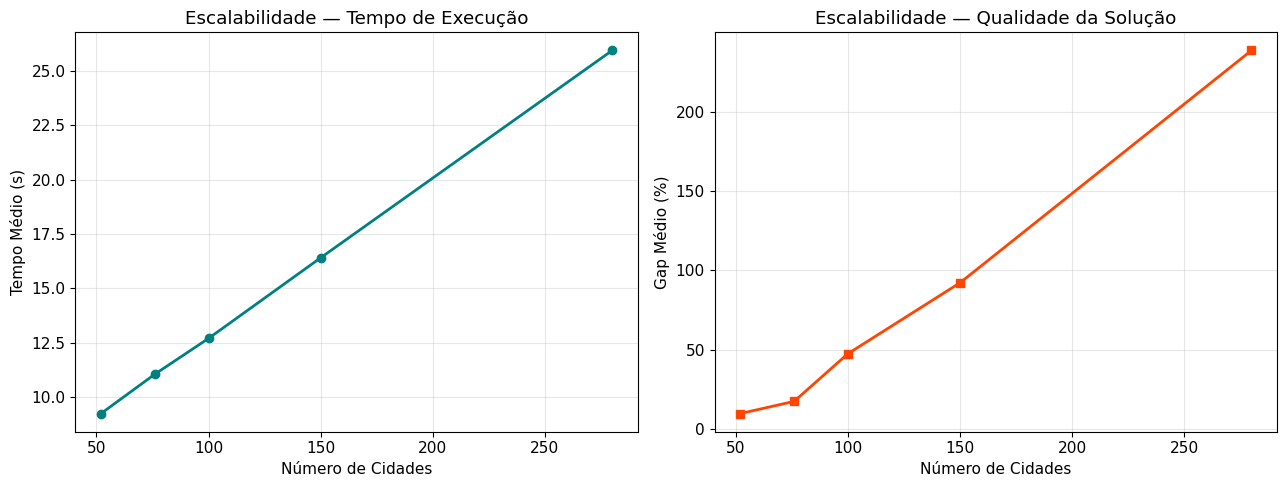

In [18]:
if len(all_stats) >= 2:
    plot_scalability(all_stats,
                     save_path=os.path.join(OUTPUT_DIR, "escalabilidade.png"))
else:
    print("Precisa de ao menos 2 instâncias para o gráfico de escalabilidade.")

## 15. Conclusões e Observações para o Relatório

### Pontos a discutir no relatório técnico:

1. **Convergência**: O AG converge rapidamente nas primeiras gerações e depois estabiliza. Isso é esperado — a população perde diversidade e o progresso depende cada vez mais de mutações benéficas.

2. **Qualidade da solução**: O gap percentual tende a aumentar com o número de cidades, pois instâncias maiores têm espaços de busca exponencialmente maiores.

3. **Tempo de execução**: Cresce de forma superlinear com o número de cidades, principalmente porque a avaliação de cada indivíduo é O(n) e a população inteira é reavaliada a cada geração.

4. **Elitismo**: Fundamental para garantir convergência monotônica do best fitness (nunca piora).

5. **OX vs outros crossovers**: O Order Crossover preserva sub-rotas boas dos pais, sendo adequado para o TSP.

6. **Inversão vs swap**: A mutação por inversão é mais poderosa que o swap simples, pois equivale a um 2-opt move.

### Possíveis melhorias (para mencionar como trabalho futuro):
- Aumentar a população e gerações para instâncias maiores
- Implementar busca local (2-opt) como operador de melhoria
- Usar mutação adaptativa (taxa variável ao longo das gerações)
- Implementar crossover alternativo (PMX, CX)